## Mejor clasificación para CIFAR10 y redes convolucionales

El objetivo de esta actividad es trascender la implementación mecánica de modelos y adentrarse en el proceso de diseño arquitectónico de redes convolucionales. Utilizando el conjunto de datos CIFAR-10, deberás desarrollar un modelo de aprendizaje profundo que maximice la precisión en el conjunto de test, fundamentando cada decisión técnica en base a la experimentación empírica.



El notebook debe documentar el ciclo de vida del desarrollo. Se espera ver al menos tres iteraciones significativas partiendo de un modelo base.  La arquitectura debe ser original. No se permite el uso directo de modelos conocidos. Se deben justificar las dimensiones de los filtros, el uso de padding, el valor del stride y la configuración de las capas de activación.



El rendimiento no es el único factor de éxito. Se valorará especialmente la capacidad crítica para interpretar las curvas de pérdida y precisión (accuracy), así como la honestidad académica en la documentación de pruebas fallidas.



Al finalizar el entrenamiento, realiza una auditoría visual de los pesos o de los mapas de activación para asegurar que la red está aprendiendo características semánticas y no aprovechando "atajos" o correlaciones espúreas en los datos.



No se evaluará únicamente la respuesta correcta, sino el razonamiento y el proceso de investigación.

In [ ]:
import os
try:
    from google.colab import drive
    COLAB = True
    print("Estoy en Google CoLab")
    !pip install livelossplot
    !pip install keras-tuner
except:
    os.environ["CUDA_VISIBLE_DEVICES"]="1"
    print("No estoy en Google CoLab")
    COLAB = False
import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, concatenate
import kerastuner as kt
import pathlib
import os
import pickle as pk
import numpy as np
from matplotlib import pyplot as plt
from livelossplot import PlotLossesKerasTF


Estoy en Google CoLab
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 12.6 MB/s eta 0:00:00


/tmp/ipykernel_15585/523556701.py:15: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  import kerastuner as kt


### Descarga y carga de los datos

In [ ]:
# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize image data to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# One-hot encode the labels
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)


print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 10)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 10)


### Modelo convolucional base

```
Versión -> 0
```


* Vamos a empezar con filtros de 32 y 64 de tamaño 3x3, por tratarse de imagenes de dimensión reducida.

* Vamos a aplicar padding, para poder usar el kernel sobre los pixeles de los bordes debido a que el tamaño de las imagenes es muy reducido 32x32 y queremos aprovechar toda la información posible.

* Vamos a aplicar Stride = 1, por mantener la idea de no perder información mediante saltos de pixeles en la aplicación del kernel.

* Vamos a usar activaciones ReLU por ser eficiente y vista en clase, con iniciación he_normal (que esta pensada para mantener una buena propagación entre capas mediante activación ReLU).

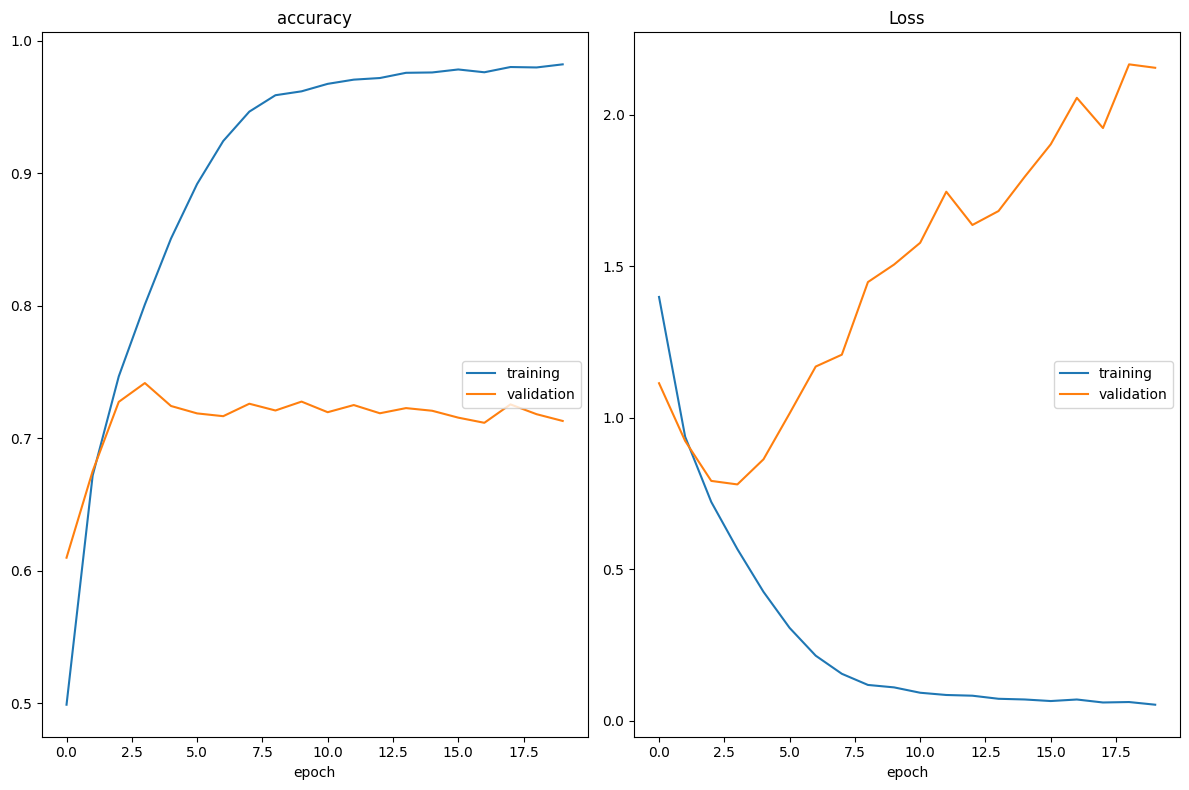

accuracy
	training         	 (min:    0.499, max:    0.982, cur:    0.982)
	validation       	 (min:    0.610, max:    0.742, cur:    0.713)
Loss
	training         	 (min:    0.053, max:    1.399, cur:    0.053)
	validation       	 (min:    0.780, max:    2.167, cur:    2.156)
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9821 - loss: 0.0531 - val_accuracy: 0.7130 - val_loss: 2.1558


In [ ]:
inputs = tf.keras.Input(shape=(32, 32, 3))

# Convoluciones
# Bloque 1
x = tf.keras.layers.Conv2D(32, (3,3), padding='same', kernel_initializer='he_normal')(inputs)

x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Conv2D(32, (3,3), padding='same', kernel_initializer='he_normal')(x)

x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.MaxPooling2D((2,2))(x)


# Bloque 2
x = tf.keras.layers.Conv2D(64, (3,3), padding='same', kernel_initializer='he_normal')(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Conv2D(64, (3,3), padding='same',kernel_initializer='he_normal')(x)

x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.MaxPooling2D((2,2))(x)


# Clasificador
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(256, kernel_initializer='he_normal')(x)
x = tf.keras.layers.Activation('relu')(x)

outputs = tf.keras.layers.Dense(10, activation='softmax')(x)
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# Rendimiento
model.compile(optimizer='adam', metrics=['accuracy'],
              loss='categorical_crossentropy' )
model.fit(X_train, y_train, validation_data=(X_test, y_test),
          epochs=20, batch_size=64, callbacks=[PlotLossesKerasTF()])

#### Interpretación del rendimiento obtenido

Los resultados muestran que el **accuracy:**
* Para el conjunto de entrenamiento crece rápidamente en las primeras époocas, hasta estabilizarse a partir de la época 7 con valores de accuracy próximos a $0.95$ muy buenos.
* En cambio, para el conjunto de validación obtenemos un crecimiento solo hasta la 2 época, que luego parece estabilizarse entorno a valores de $[0.7,0.75]$

Los resultados muestran que para la entropía cruzada **Loss:**
* Para el conjunto de entrenamiento presenta una gran decreciente hasta la estabilizarse a partir de la época 7, obteniendo resultados por debajo de $0.2$ muy buenos.
* En cambio, para el conjunto de validación obtenemos un decrecimiento hasta la 2 época, que luego presenta un aumento constante.

En conclusión:
* Para el conjunto de entrenamineto obtenemos un buen comportamiento
* Pero para el conjunto de validación. No solo no conseguimos aumentar el porcentaje de aciertos sobre las instancias de validación sino que, por la gráfica loss, podemos observar que además las probabilidades donde se equivoca son cada vez mayores otorgando una mayor perdida de entropía cruzada.

Por lo que, el modelo parece presentar algún tipo de overffiting.

### Modelo convolucional mejorado
```
 Versión -> 1
```

Para intentar corregir el overffiting, vamos a aplicar Dropout, Stride y penalización L2 para tratar de reducir el sesgo introducido por el conjunto de entrenamiento.

Para ello, vamos a empezar con:
* Dropout = 0.5 para poner a 0 el 50% de las entradas antes de la capa densa(256)
* Stride = (2,2), salta 1 pixel horizontal y vertical cuando se aplique el kernel, para el bloque 2 de convoluciones
* Regularización L2 con hiperparámetro regularizers.l2(0.001) para los pesos de la capa densa.

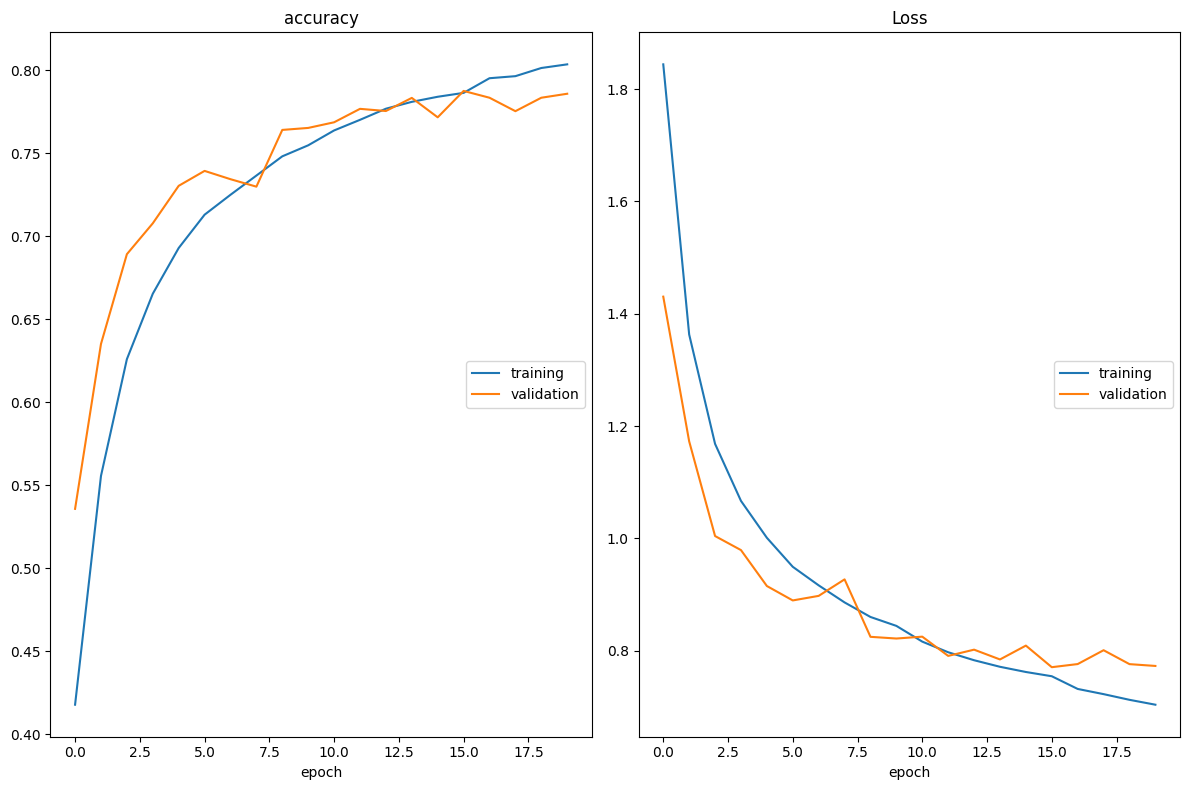

accuracy
	training         	 (min:    0.418, max:    0.804, cur:    0.804)
	validation       	 (min:    0.536, max:    0.788, cur:    0.786)
Loss
	training         	 (min:    0.704, max:    1.844, cur:    0.704)
	validation       	 (min:    0.771, max:    1.430, cur:    0.773)
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8036 - loss: 0.7040 - val_accuracy: 0.7859 - val_loss: 0.7730


In [ ]:
inputs = tf.keras.Input(shape=(32, 32, 3))

# Convoluciones
# Bloque 1
x = tf.keras.layers.Conv2D(32, (3,3), padding='same', kernel_initializer='he_normal')(inputs)

x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Conv2D(32, (3,3), padding='same', kernel_initializer='he_normal')(x)

x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.MaxPooling2D((2,2))(x)


# Bloque 2
x = tf.keras.layers.Conv2D(64, (3,3), strides=(2, 2), padding='same', kernel_initializer='he_normal')(x) #Stride
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Conv2D(64, (3,3), padding='same',kernel_initializer='he_normal')(x)

x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.MaxPooling2D((2,2))(x)


# Clasificador
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dropout(0.5)(x) #Dropout
x = tf.keras.layers.Dense(
    256,
    kernel_initializer='he_normal',
    kernel_regularizer=regularizers.l2(0.001)   # penaliza los pesos con L2
)(x)
x = tf.keras.layers.Activation('relu')(x)

outputs = tf.keras.layers.Dense(10, activation='softmax')(x)
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# Rendimiento
model.compile(optimizer='adam', metrics=['accuracy'],
              loss='categorical_crossentropy' )
model.fit(X_train, y_train, validation_data=(X_test, y_test),
          epochs=20, batch_size=64, callbacks=[PlotLossesKerasTF()])

Hemos reducido drásticamente el problema del overffiting. Pero hemos elegido unos hiperparámetros iniciales predeterminados, veamos que sucede si reducimos el **Dropout** a $0.3$ y aumentamos la penalización **L2** a $0.005$.

Además vamos a aumentar el número de épocas, ya que al reducir el aprendizaje sobre el conjunto de entrenamiento (para reducir el sesgo) es posible que necesitemos más épocas de entrenamiento para alcanzar un mayor rendimiento.

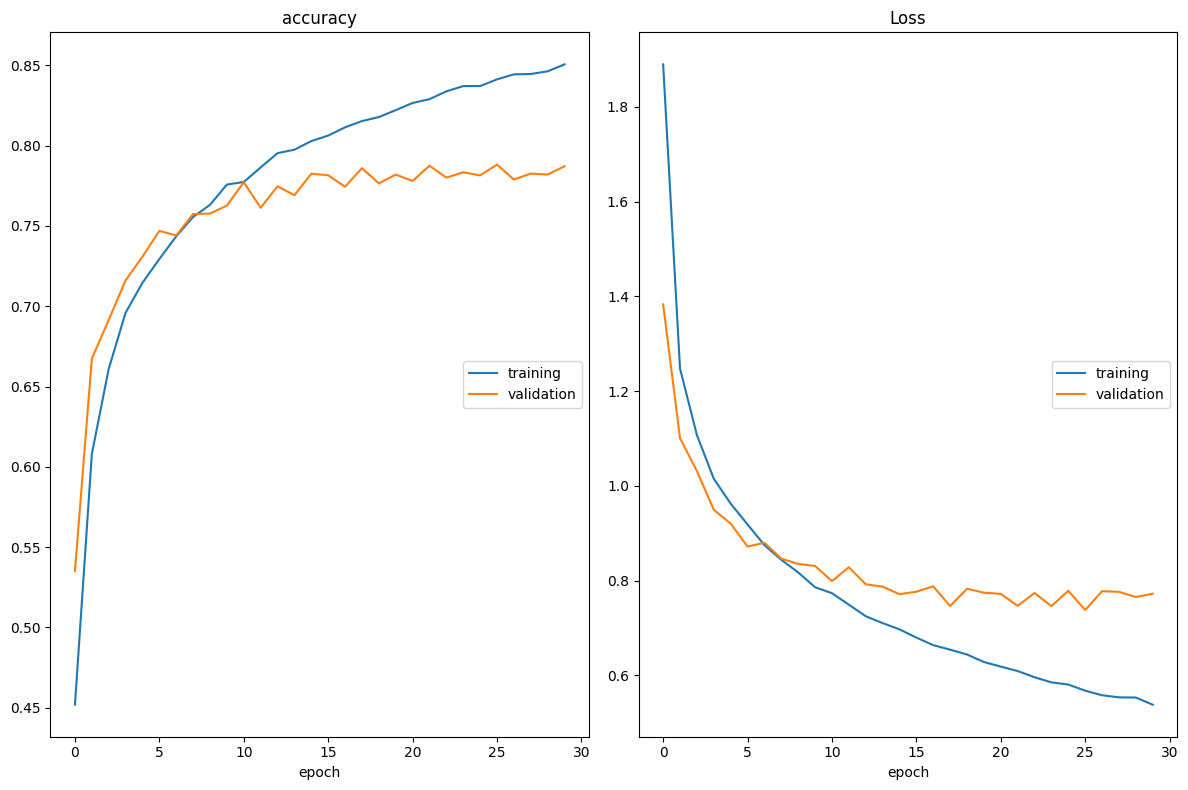

accuracy
	training         	 (min:    0.452, max:    0.851, cur:    0.851)
	validation       	 (min:    0.535, max:    0.788, cur:    0.787)
Loss
	training         	 (min:    0.538, max:    1.890, cur:    0.538)
	validation       	 (min:    0.738, max:    1.383, cur:    0.772)
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8506 - loss: 0.5382 - val_accuracy: 0.7872 - val_loss: 0.7724


In [ ]:
inputs = tf.keras.Input(shape=(32, 32, 3))

# Convoluciones
# Bloque 1
x = tf.keras.layers.Conv2D(32, (3,3), padding='same', kernel_initializer='he_normal')(inputs)

x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Conv2D(32, (3,3), padding='same', kernel_initializer='he_normal')(x)

x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.MaxPooling2D((2,2))(x)


# Bloque 2
x = tf.keras.layers.Conv2D(64, (3,3), strides=(2, 2), padding='same', kernel_initializer='he_normal')(x) #Stride
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Conv2D(64, (3,3), padding='same',kernel_initializer='he_normal')(x)

x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.MaxPooling2D((2,2))(x)


# Clasificador
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dropout(0.3)(x) #Dropout
x = tf.keras.layers.Dense(
    256,
    kernel_initializer='he_normal',
    kernel_regularizer=regularizers.l2(0.005)   # penaliza los pesos con L2
)(x)
x = tf.keras.layers.Activation('relu')(x)

outputs = tf.keras.layers.Dense(10, activation='softmax')(x)
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# Rendimiento
model.compile(optimizer='adam', metrics=['accuracy'],
              loss='categorical_crossentropy' )
model.fit(X_train, y_train, validation_data=(X_test, y_test),
          epochs=30, batch_size=64, callbacks=[PlotLossesKerasTF()])

Observamos que los resultados para la variación de hiperparametros es diferente, lo que sugiere que debamos encontrar cual es la mejor combinación para nuestro modelo.

Para ello, vamos usar **Keras Tuner** que nos permite probar combinaciones de hiperparámetros de penalización L2 y Dropout, para obtener aquella dupla que consigue el mejor rendimiento sobre el conjunto de validación.

Además, las gráfias obtenidas anteriormente sugieren que aumentar el número de épocas de entrenamiento puede proporcionar alguna mejoría.

In [ ]:
def build_model(hp):
    inputs = tf.keras.Input(shape=(32, 32, 3))

    # Convoluciones
    # Bloque 1
    x = tf.keras.layers.Conv2D(32, (3,3), padding='same', kernel_initializer='he_normal')(inputs)

    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2D(32, (3,3), padding='same', kernel_initializer='he_normal')(x)

    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D((2,2))(x)


    # Bloque 2
    x = tf.keras.layers.Conv2D(64, (3,3), padding='same', kernel_initializer='he_normal')(x) #Stride
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2D(64, (3,3), padding='same',kernel_initializer='he_normal')(x)

    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D((2,2))(x)

    # Optimizar hiperparametros
    dropout = hp.Float('dropout', 0.2, 0.5, step=0.1)
    regu   = hp.Float('l2', 0.001, 0.005, step=0.001)

    # Clasificador
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dropout(dropout)(x)
    x = tf.keras.layers.Dense(256,
        kernel_initializer='he_normal',
        kernel_regularizer=tf.keras.regularizers.l2(regu)
    )(x)
    x = tf.keras.layers.Activation('relu')(x)

    outputs = tf.keras.layers.Dense(10, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', metrics=['accuracy'],
                  loss='categorical_crossentropy' )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20
)

tuner.search(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30
)

best_model = tuner.get_best_models()[0]


Trial 15 Complete [00h 04m 09s]
val_accuracy: 0.7978000044822693

Best val_accuracy So Far: 0.8034999966621399
Total elapsed time: 00h 49m 31s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Mejor rendimiento encontrado para:
* **Dropout = 0.4**
* **L2 = 0.002**

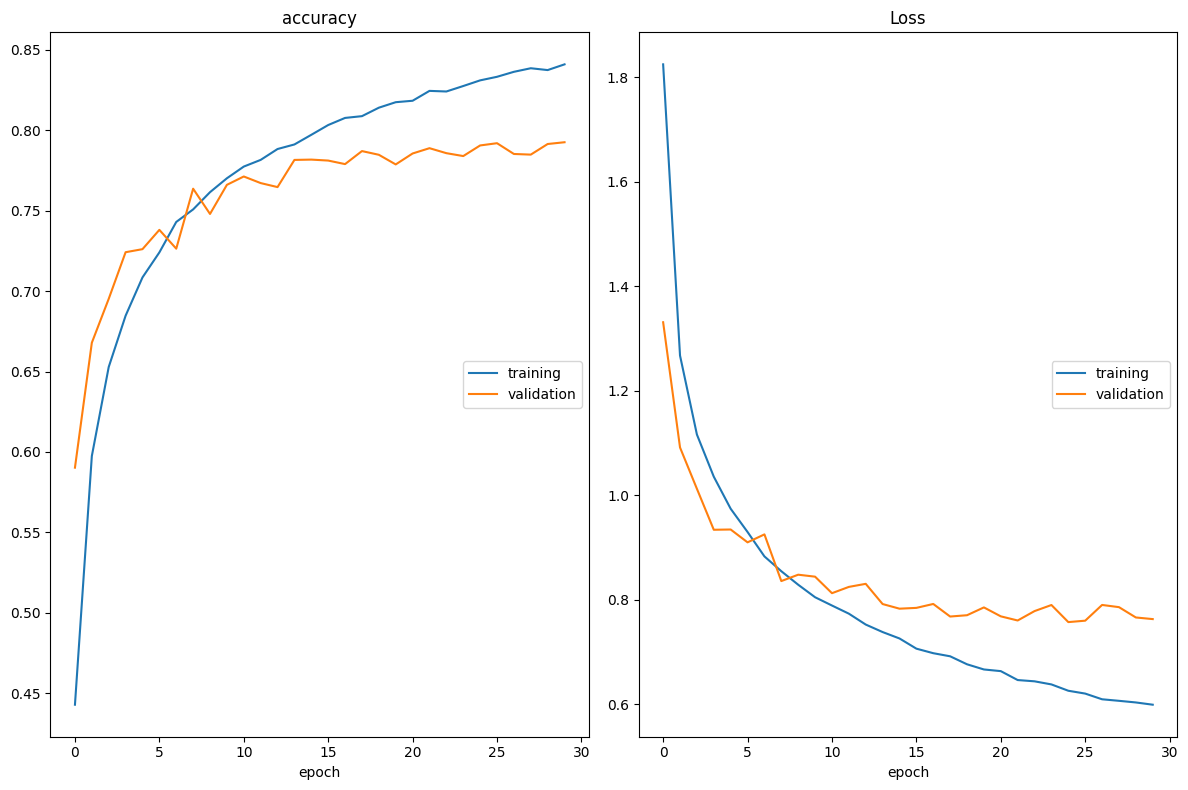

accuracy
	training         	 (min:    0.443, max:    0.841, cur:    0.841)
	validation       	 (min:    0.590, max:    0.793, cur:    0.793)
Loss
	training         	 (min:    0.599, max:    1.825, cur:    0.599)
	validation       	 (min:    0.757, max:    1.331, cur:    0.763)
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8410 - loss: 0.5991 - val_accuracy: 0.7926 - val_loss: 0.7630


In [ ]:
drop = 0.4
penalizacion = 0.002

inputs = tf.keras.Input(shape=(32, 32, 3))

# Convoluciones
# Bloque 1
x = tf.keras.layers.Conv2D(32, (3,3), padding='same', kernel_initializer='he_normal')(inputs)

x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Conv2D(32, (3,3), padding='same', kernel_initializer='he_normal')(x)

x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.MaxPooling2D((2,2))(x)


# Bloque 2
x = tf.keras.layers.Conv2D(64, (3,3), strides=(2, 2), padding='same', kernel_initializer='he_normal')(x) #Stride
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Conv2D(64, (3,3), padding='same',kernel_initializer='he_normal')(x)

x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.MaxPooling2D((2,2))(x)


# Clasificador
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dropout(drop)(x) #Dropout
x = tf.keras.layers.Dense(
    256,
    kernel_initializer='he_normal',
    kernel_regularizer=regularizers.l2(penalizacion)   # penaliza los pesos con L2
)(x)
x = tf.keras.layers.Activation('relu')(x)

outputs = tf.keras.layers.Dense(10, activation='softmax')(x)
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# Rendimiento
model.compile(optimizer='adam', metrics=['accuracy'],
              loss='categorical_crossentropy' )
model.fit(X_train, y_train, validation_data=(X_test, y_test),
          epochs=30, batch_size=64, callbacks=[PlotLossesKerasTF()])

#### Interpretación del rendimiento obtenido

Los resultados muestran que el **accuracy:**
* Para el conjunto de entrenamiento se ha visto reducido considerablemente, que era justo lo que tratabamos (debido a que al lograr valores próximos a 1 para el conjunto de entrenamiento, estamos sesgando el modelo para los datos de validación).
* Hemos logrado un crecimiento a en las primeras 10 épocas parecido al conjunto de entrenamiento y luego estabilizarse entorno a valores de $[0.75,0.8]$. Lo cual presenta una mejoría respecto a la versión anterior.

Los resultados muestran que para la entropía cruzada **Loss:**
* Para el conjunto de entrenamiento presenta una gran decreciente hasta la estabilizarse a partir de la época 7, obteniendo resultados por debajo de $0.2$ muy buenos.
* En cambio, para el conjunto de validación obtenemos un decrecimiento hasta la 2 época, que luego presenta un aumento constante.

En conclusión:
* Para el conjunto de entrenamineto obtenemos un peor rendimiento, debido a la pérdida de acuracy.
* Para el conjunto de validación observamos una gran mejoría. Hemos conseguido un decrecimiento hasta las primeras 10/15 épocas y estibilizarse entorno a valores de $0.8$.

Por lo que, el modelo parece presentar un gran avance respecto a la versión anterior. Podemos tratar de mejorar el acuracy para el conjunto de validación tratando de dotar al modelo de una arquitectura que le proporcione una mejor compresión de los rasgos de las imagenes.

### Modelo convolucional mejorado
```
 Versión -> 2
```
Vamos a basarnos en la idea que vimos en clase de los bloques Inception, para tratar de donar al modelo de una arquitectura capaz de captar mejores rasgos.

Para ello usaremos:
* Filtros convolucionales $(1\times 1, C)$ para matener $H \times W$ (altura x anchura) pero cambiar tamaño de filtros a $C$.
* Aplicar concadenación al final de cada bloque inception de manera que, si cada rama $i$ devuelve tensores de dimensión $H \times W \times C_i$, despues de concatenar obtenemos $H \times W \times \sum_i C_i$ (es importante para esta parte, apliquemos padding = same y MaxPool con stride =1. Ya que en caso contrario, estaríamos reduciendo la dimensión $H x W$)
* El primer bloque inception tiene filtros de tamaño 32 y 16 para observar detalles más finos. Y el segundo de tamañor 64 y 32 para aumentar la región.

#### **Arquitectura con bloques Inception**

**Input**  
x = (32×32×3)

* **InceptionBlock1(x)**
  - Rama 1: `Conv(1×1, 32, ReLU)` $= H \times W \times 32$
  - Rama 2: `Conv(1×1, 32, ReLU)` → `Conv(3×3, 32, padding = same, ReLU)` $= H \times W \times 32$
  - Rama 3: `Conv(1×1, 16, ReLU)` → `Conv(5×5, 16, padding = same, ReLU)` $= H \times W \times 16$
  - Rama 4: `MaxPool(3×3, stride=1)` → `Conv(1×1, 16, ReLU)`  $= H \times W \times 16$

  → **Concat (canales)$ = H \times W \times 96$**  
  → **MaxPool(2×2)$ = \frac{H}{2} \times \frac{W}{2} \times 96$**

* **InceptionBlock2(InceptionBlock1(x))**
  - Rama 1: `Conv(1×1, 64)`$= \frac{H}{2} \times \frac{W}{2} \times 64$
  - Rama 2: `Conv(1×1, 64)` → `Conv(3×3, 64)`$= \frac{H}{2} \times \frac{W}{2} \times 64$
  - Rama 3: `Conv(1×1, 32)` → `Conv(5×5, 32)`$= \frac{H}{2} \times \frac{W}{2} \times 32$
  - Rama 4: `MaxPool(3×3, stride=1)` → `Conv(1×1, 32)`$= \frac{H}{2} \times \frac{W}{2} \times 32$  
  → **Concat (canales)$ = \frac{H}{2} \times \frac{W}{2} \times 192$**  
  → **MaxPool(2×2)$= \frac{H}{4} \times \frac{W}{4} \times 192$**

**Clasificador final**

Lo dejamos como estaba:
- **Flatten**
- **Dropout**  
- **Dense(256)** con regularización **L2** → **ReLU**
- **Dense(10)** → **Softmax**



In [ ]:
def inception_block(x, filters_1x1=32, filters_3x3=32, filters_5x5=16, filters_pool=16):
    # Rama 1: 1x1
    branch1 = Conv2D(filters_1x1, (1,1), padding='same', activation='relu',
                     kernel_initializer='he_normal')(x)

    # Rama 2: 1x1 -> 3x3
    branch2 = Conv2D(filters_3x3, (1,1), padding='same', activation='relu',
                     kernel_initializer='he_normal')(x)
    branch2 = Conv2D(filters_3x3, (3,3), padding='same', activation='relu',
                     kernel_initializer='he_normal')(branch2)

    # Rama 3: 1x1 -> 5x5
    branch3 = Conv2D(filters_5x5, (1,1), padding='same', activation='relu',
                     kernel_initializer='he_normal')(x)
    branch3 = Conv2D(filters_5x5, (5,5), padding='same', activation='relu',
                     kernel_initializer='he_normal')(branch3)# Vimos en clase que tambien vale con aplicar 2 filtros 3x3

    # Rama 4: 3x3 max pool -> 1x1
    branch4 = MaxPooling2D((3,3), strides=(1,1), padding='same')(x)
    branch4 = Conv2D(filters_pool, (1,1), padding='same', activation='relu',
                     kernel_initializer='he_normal')(branch4)

    # Concatenar en canales
    x = concatenate([branch1, branch2, branch3, branch4], axis=-1)
    return x

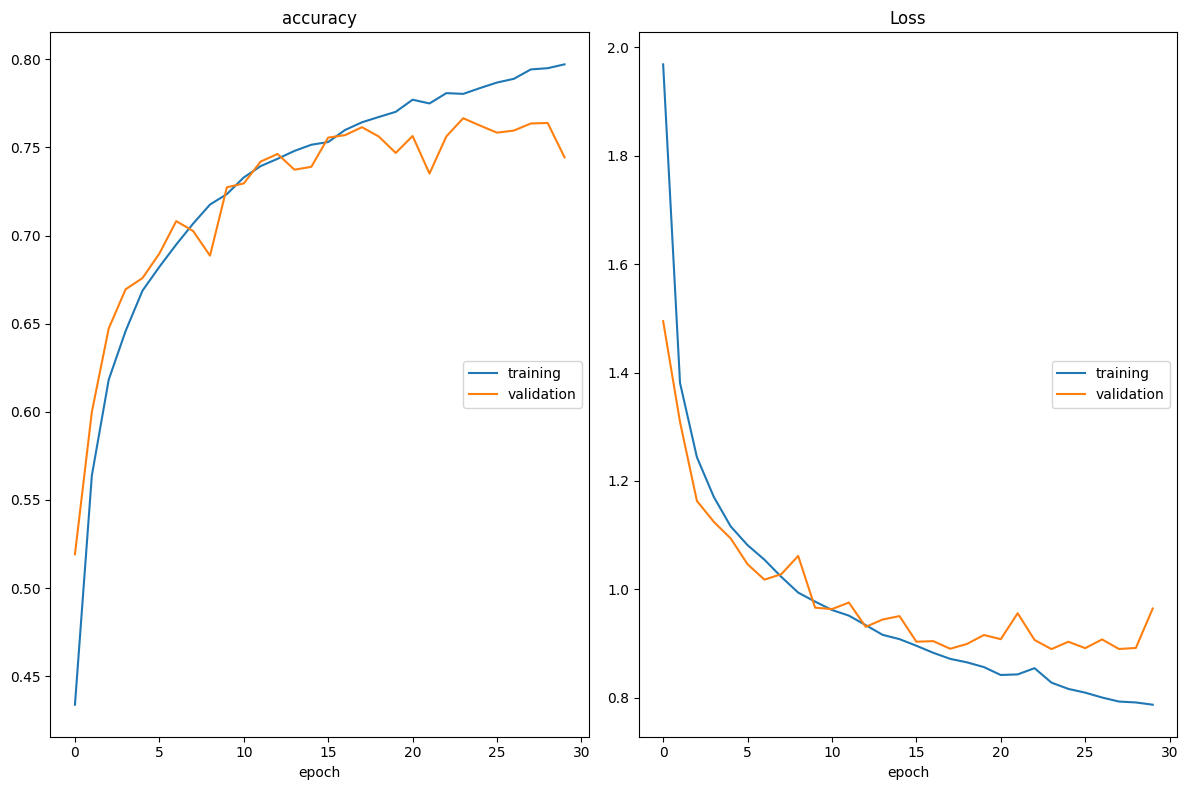

accuracy
	training         	 (min:    0.434, max:    0.797, cur:    0.797)
	validation       	 (min:    0.519, max:    0.767, cur:    0.744)
Loss
	training         	 (min:    0.787, max:    1.969, cur:    0.787)
	validation       	 (min:    0.890, max:    1.495, cur:    0.965)
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.7972 - loss: 0.7873 - val_accuracy: 0.7444 - val_loss: 0.9648


In [ ]:
inputs = tf.keras.Input(shape=(32, 32, 3))

# Bloque 1 tipo Inception
x = inception_block(inputs, 32, 32, 16, 16)
x = MaxPooling2D((2,2))(x)

# Bloque 2 tipo Inception
x = inception_block(x, 64, 64, 32, 32)
x = MaxPooling2D((2,2))(x)

# Clasificador
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dropout(0.5)(x) #Dropout
x = tf.keras.layers.Dense(
    256,
    kernel_initializer='he_normal',
    kernel_regularizer=regularizers.l2(0.005)   # penaliza los pesos con L2
)(x)
x = tf.keras.layers.Activation('relu')(x)

outputs = tf.keras.layers.Dense(10, activation='softmax')(x)
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# Rendimiento
model.compile(optimizer='adam', metrics=['accuracy'],
              loss='categorical_crossentropy' )
model.fit(X_train, y_train, validation_data=(X_test, y_test),
          epochs=30, batch_size=64, callbacks=[PlotLossesKerasTF()])


Puede que con los nuevos valores de los hiperparámetros de **Dropout** y **L2**

Para corregirlo, vamos a aumentar las épocas de 30->50 y disminuir **Dropout/L2** 0.5->0.2 / 0.005->0.004

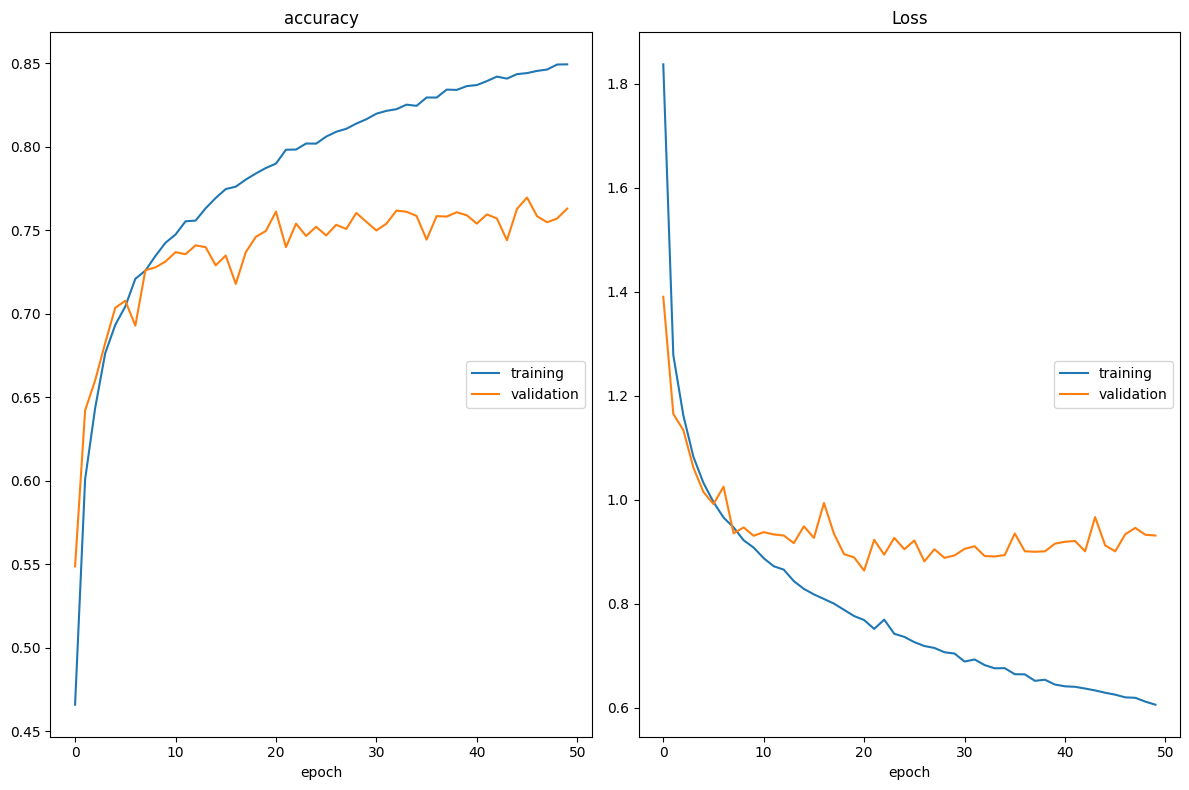

accuracy
	training         	 (min:    0.466, max:    0.849, cur:    0.849)
	validation       	 (min:    0.549, max:    0.770, cur:    0.763)
Loss
	training         	 (min:    0.605, max:    1.838, cur:    0.605)
	validation       	 (min:    0.864, max:    1.390, cur:    0.931)
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8492 - loss: 0.6054 - val_accuracy: 0.7629 - val_loss: 0.9310


In [ ]:
inputs = tf.keras.Input(shape=(32, 32, 3))

# Bloque 1 tipo Inception
x = inception_block(inputs, 32, 32, 16, 16)
x = MaxPooling2D((2,2))(x)

# Bloque 2 tipo Inception
x = inception_block(x, 64, 64, 32, 32)
x = MaxPooling2D((2,2))(x)

# Clasificador
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dropout(0.2)(x) #Dropout
x = tf.keras.layers.Dense(
    256,
    kernel_initializer='he_normal',
    kernel_regularizer=regularizers.l2(0.004)   # penaliza los pesos con L2
)(x)
x = tf.keras.layers.Activation('relu')(x)

outputs = tf.keras.layers.Dense(10, activation='softmax')(x)
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# Rendimiento
model.compile(optimizer='adam', metrics=['accuracy'],
              loss='categorical_crossentropy' )
model.fit(X_train, y_train, validation_data=(X_test, y_test),
          epochs=50, batch_size=64, callbacks=[PlotLossesKerasTF()])


Observando las nuevas gráficas, podemos estar ahora tratando de un caso de overffiting.

Igual que hicimos en la versión 1 del modelo, vamos a usar **Keras tuner** para obtener la mejor combinación de hiperparámetros.

In [ ]:
def build_model(hp):
    inputs = tf.keras.Input(shape=(32, 32, 3))

    # Convoluciones Inception
    # Bloque 1 tipo Inception
    x = inception_block(inputs, 32, 32, 16, 16)
    x = MaxPooling2D((2,2))(x)

    # Bloque 2 tipo Inception
    x = inception_block(x, 64, 64, 32, 32)
    x = MaxPooling2D((2,2))(x)


    # Optimizar hiperparametros
    dropout = hp.Float('dropout', 0.1, 0.5, step=0.1)
    regu   = hp.Float('l2', 0.001, 0.005, step=0.001)

    # Clasificador
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dropout(dropout)(x)
    x = tf.keras.layers.Dense(256,
        kernel_initializer='he_normal',
        kernel_regularizer=tf.keras.regularizers.l2(regu)
    )(x)
    x = tf.keras.layers.Activation('relu')(x)

    outputs = tf.keras.layers.Dense(10, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', metrics=['accuracy'],
                  loss='categorical_crossentropy' )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20
)

tuner.search(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50
)

best_model = tuner.get_best_models()[0]



Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
0.5               |0.5               |dropout
0.001             |0.001             |l2

Epoch 1/50


: 



> *Comentario personal:* En colab no me han dejado seguir usando GPU y he tenido que usar directamente mi ordenador. Lo he ejecutado como archivo .py y los resultados son:


Best val_accuracy So Far: 0.7932000160217285
Total elapsed time: 01h 13m 17s

Search: Running Trial #8

| Value | Best Value So Far | Hyperparameter |
|-------|-------------------|----------------|
| 0.3   | 0.5               | dropout        |
| 0.004 | 0.001             | l2             |


Best val_accuracy So Far: 0.7932000160217285
Total elapsed time: 02h 50m 58s

Search: Running Trial #17

| Value | Best Value So Far | Hyperparameter |
|-------|-------------------|----------------|
| 0.1   | 0.5               | dropout        |
| 0.004 | 0.001             | l2             |


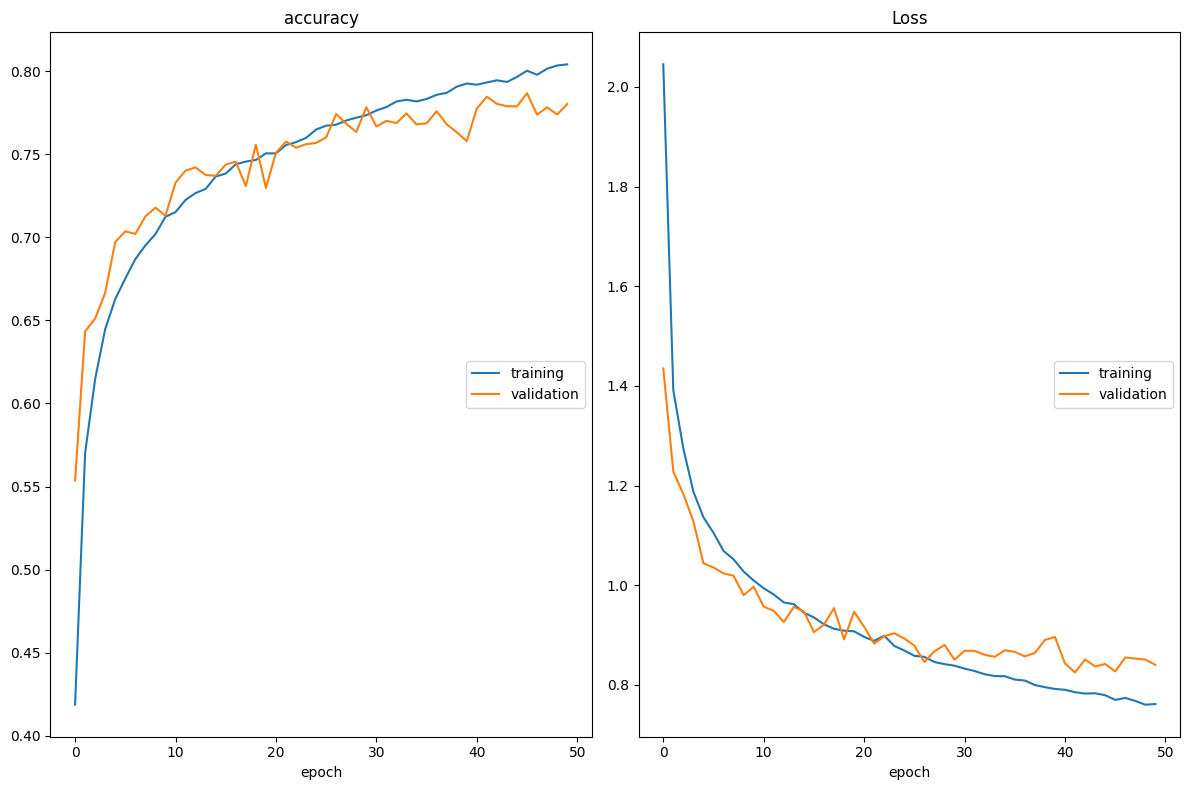

accuracy
	training         	 (min:    0.419, max:    0.804, cur:    0.804)
	validation       	 (min:    0.554, max:    0.787, cur:    0.780)
Loss
	training         	 (min:    0.760, max:    2.045, cur:    0.762)
	validation       	 (min:    0.825, max:    1.435, cur:    0.840)
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8041 - loss: 0.7615 - val_accuracy: 0.7802 - val_loss: 0.8401


In [ ]:
inputs = tf.keras.Input(shape=(32, 32, 3))

# Bloque 1 tipo Inception
x = inception_block(inputs, 32, 32, 16, 16)
x = MaxPooling2D((2,2))(x)

# Bloque 2 tipo Inception
x = inception_block(x, 64, 64, 32, 32)
x = MaxPooling2D((2,2))(x)

# Clasificador
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dropout(0.5)(x) #Dropout
x = tf.keras.layers.Dense(
    256,
    kernel_initializer='he_normal',
    kernel_regularizer=regularizers.l2(0.004)   # penaliza los pesos con L2
)(x)
x = tf.keras.layers.Activation('relu')(x)

outputs = tf.keras.layers.Dense(10, activation='softmax')(x)
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# Rendimiento
model.compile(optimizer='adam', metrics=['accuracy'],
              loss='categorical_crossentropy' )
model.fit(X_train, y_train, validation_data=(X_test, y_test),
          epochs=50, batch_size=64, callbacks=[PlotLossesKerasTF()])


Parece que puede seguir presentando un mejor rendimiento si lo dejamos entrenar más épocas.

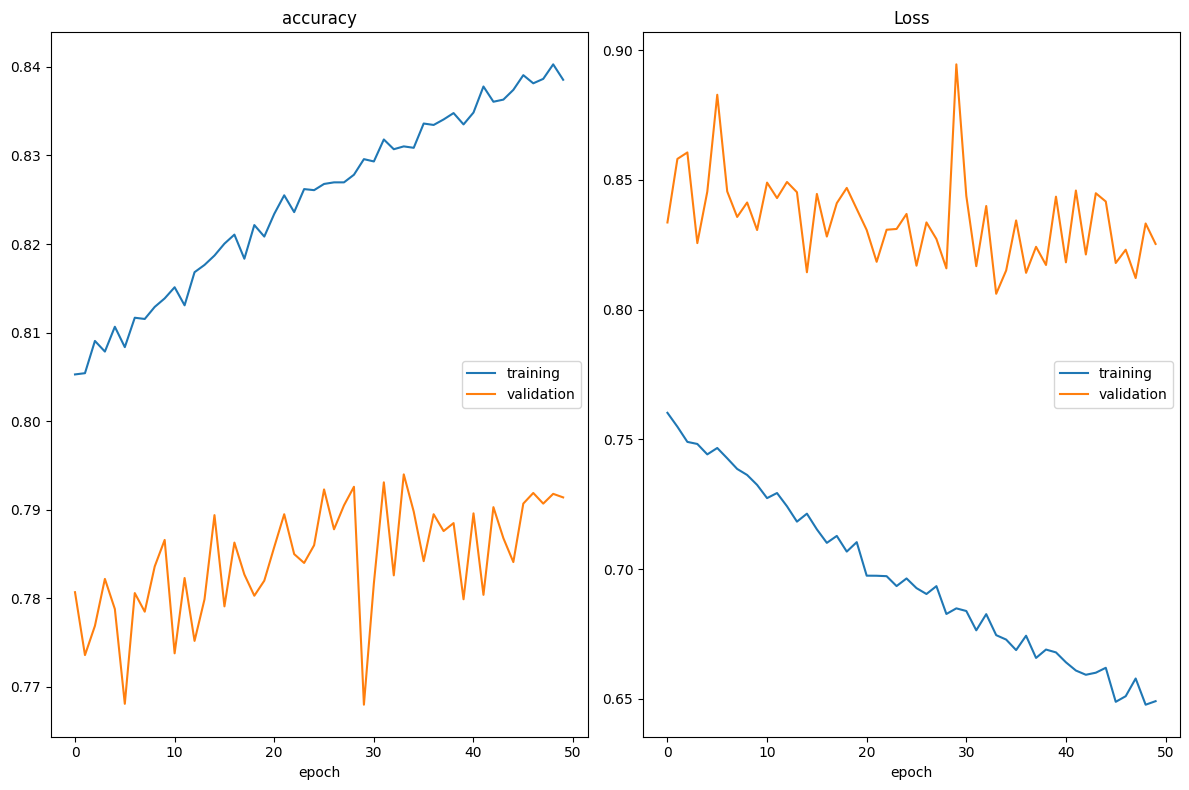

accuracy
	training         	 (min:    0.805, max:    0.840, cur:    0.839)
	validation       	 (min:    0.768, max:    0.794, cur:    0.791)
Loss
	training         	 (min:    0.648, max:    0.760, cur:    0.649)
	validation       	 (min:    0.806, max:    0.895, cur:    0.825)
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8385 - loss: 0.6491 - val_accuracy: 0.7914 - val_loss: 0.8253


In [ ]:
model.fit(X_train, y_train, validation_data=(X_test, y_test),
          epochs=50, batch_size=64, callbacks=[PlotLossesKerasTF()])

#### Interpretación del rendimiento obtenido

Los resultados muestran que el **accuracy:**

* Hemos logrado un crecimiento similar tanto para el conjunto de entrenamiento como el de validación. Llegando a valores próximos a $0.8$ para el conjunto de validación.

Los resultados muestran que para la entropía cruzada **Loss:**

* Ambos conjunto obtienen pérdidas similares, próximas a $0.8$. Logrando un buen rendimiento.

En conclusión:
Al lograr un rendimiento similar para el conjunto de entrenamiento y validación, sugiere que hemos dado con una buena arquitectura y balance de underffiting/overffiting. Para conseguir mejores resultado, igual necesitariamos reestructurar la arquitectura del modelo y hacer muchas más pruebas para obtener un estudio más profundo.

### Visualización del aprendizaje del modelo

Vamos a usar código de la tarea 2, la usada para detectar las anomalías de las imagenes CIFAR10. Para representar mediante un mapa de calor los pesos de la red mediante retropropagación.

In [ ]:
# Localiza la capa Flatten de tu modelo
flatten_layer = [l for l in model.layers if isinstance(l, tf.keras.layers.Flatten)][0]

# Tensor de entrada al Flatten (salida del último MaxPooling2D)
feature_tensor = flatten_layer.input    # Nuestro caso (None, H, W, C) = (None, 8, 8, 192)

# Modelo extractor de características: imagen -> mapa de features
feature_model = tf.keras.Model(inputs=model.input, outputs=feature_tensor)

# Modelo clasificador: mapa de features -> salida softmax (reutiliza las mismas capas)
classifier = tf.keras.Model(inputs=feature_tensor, outputs=model.output)

def lrp_dense_zplus(a_in, layer, R_out, epsilon=1e-9):
    W = layer.kernel
    a_pos = tf.nn.relu(a_in)
    W_pos = tf.nn.relu(W)

    Z = tf.matmul(a_pos, W_pos) + epsilon
    S = R_out / Z
    C = tf.matmul(S, tf.transpose(W_pos))
    R_in = a_pos * C
    return R_in

def compute_lrp_classifier(classifier, x_feat, class_idx=None):
    """
    LRP solo en el clasificador (Flatten + Dense + Activation + Dense).
    x_feat: tensor (1, H, W, C) = (1, 8, 8, 192).
    Devuelve relevancia sobre (1, H, W, C)

    Luego reescalamos a (32, 32, C) para overlay en la imagen original.
    """
    x_feat = tf.cast(x_feat, tf.float32)

    non_input_layers = [
        layer for layer in classifier.layers
        if not isinstance(layer, tf.keras.layers.InputLayer)
    ]

    # Forward: guardar activaciones
    activations = [x_feat]
    for layer in non_input_layers:
        activations.append(layer(activations[-1]))

    # Relevancia inicial en la salida
    y = activations[-1]  # (1, 10)
    if class_idx is None:
        class_idx = tf.argmax(y[0])
    R = tf.one_hot(class_idx, y.shape[-1]) * y  # (1, 10)

    # Backward por las capas del clasificador (no capas convolucionales)
    for l in reversed(range(len(non_input_layers))):
        layer = non_input_layers[l]
        a_in = activations[l]

        if isinstance(layer, tf.keras.layers.Dense):
            R = lrp_dense_zplus(a_in, layer, R)
        elif isinstance(layer, tf.keras.layers.Flatten):
            # invertimos Flatten: devolvemos a (1, H, W, C)
            R = tf.reshape(R, tf.shape(a_in))
        elif isinstance(layer, (tf.keras.layers.Dropout,
                                tf.keras.layers.Activation)):
            # capas "pasivas": dejamos pasar la relevancia
            R = R
        else:
            # en este clasificador no debería haber más tipos;
            # si los hubiera, de momento las dejamos pasar sin cambio
            R = R

    return R.numpy()  # (1, H, W, C)



Veamos el mapa de calor resultante para la primera instancia.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 630ms/step


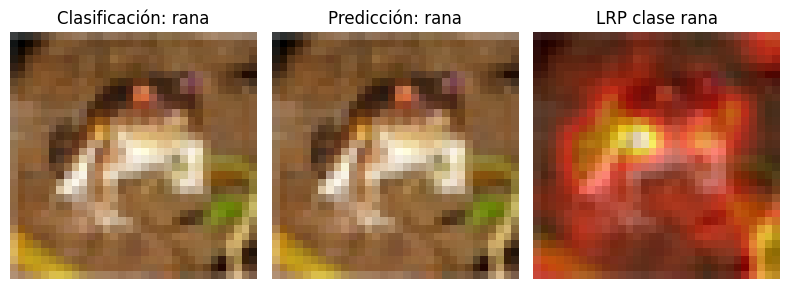

In [ ]:
idx = 0
clases = ['avión','coche','pájaro','gato','ciervo',
           'perro','rana','caballo','barco','camión']

x_img = X_train[idx:idx+1]  # (1, 32, 32, 3)
clasificacion = clases[np.argmax(y_train[idx])]
pred_proba = model.predict(x_img)
prediccion = clases[np.argmax(pred_proba[0])]

# 1) Extraemos el mapa de features (H, W, C), p.ej. (1, 8, 8, C)
x_feat = feature_model.predict(x_img)

# 2) LRP solo en el clasificador
R_feat = compute_lrp_classifier(classifier, x_feat)   # (1, H, W, C)

# 3) Normalizar y reescalar a 32x32 para overlay
R_map = R_feat[0]    # (H, W, C)
R_map = np.mean(R_map, axis=-1)   # promedio sobre canales -> (H, W)

R_norm = (R_map - R_map.min()) / (R_map.max() - R_map.min() + 1e-9)

# Reescalar al tamaño original (32x32)
R_resized = tf.image.resize(R_norm[..., np.newaxis], (32, 32)).numpy()[..., 0]

plt.figure(figsize=(8,3))

plt.subplot(1,3,1)
plt.title(f"Clasificación: {clasificacion}")
plt.imshow(X_train[idx])
plt.axis("off")

plt.subplot(1,3,2)
plt.title(f"Predicción: {prediccion}")
plt.imshow(X_train[idx])
plt.axis("off")

plt.subplot(1,3,3)
plt.title(f"LRP clase {prediccion}")
plt.imshow(X_train[idx])
plt.imshow(R_resized, cmap="hot", alpha=0.5)  # overlay
plt.axis("off")

plt.tight_layout()
plt.show()


Observamos que efectivamente, nuestro modelo resalta en especial las zonas donde se encuentra la rana. Por lo que podemos suponer, que esta comprendiendo los rasgos de la rana para clasificarla.

Veamos si esto mismo sucede con el resto de clase (código reutilizado).

In [ ]:
def indices_por_clase(y_train, clase_idx):
    """
    Devuelve índices de X_train donde la clase verdadera es clase_idx (0-9)

    Args:
        y_train: etiquetas one-hot (N, 10)
        clase_idx: clase de 0 a 9 (avión=0, coche=1, ..., camión=9)

    Returns:
        array de índices
    """

    clases_true = np.argmax(y_train, axis=1)

    return np.where(clases_true == clase_idx)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


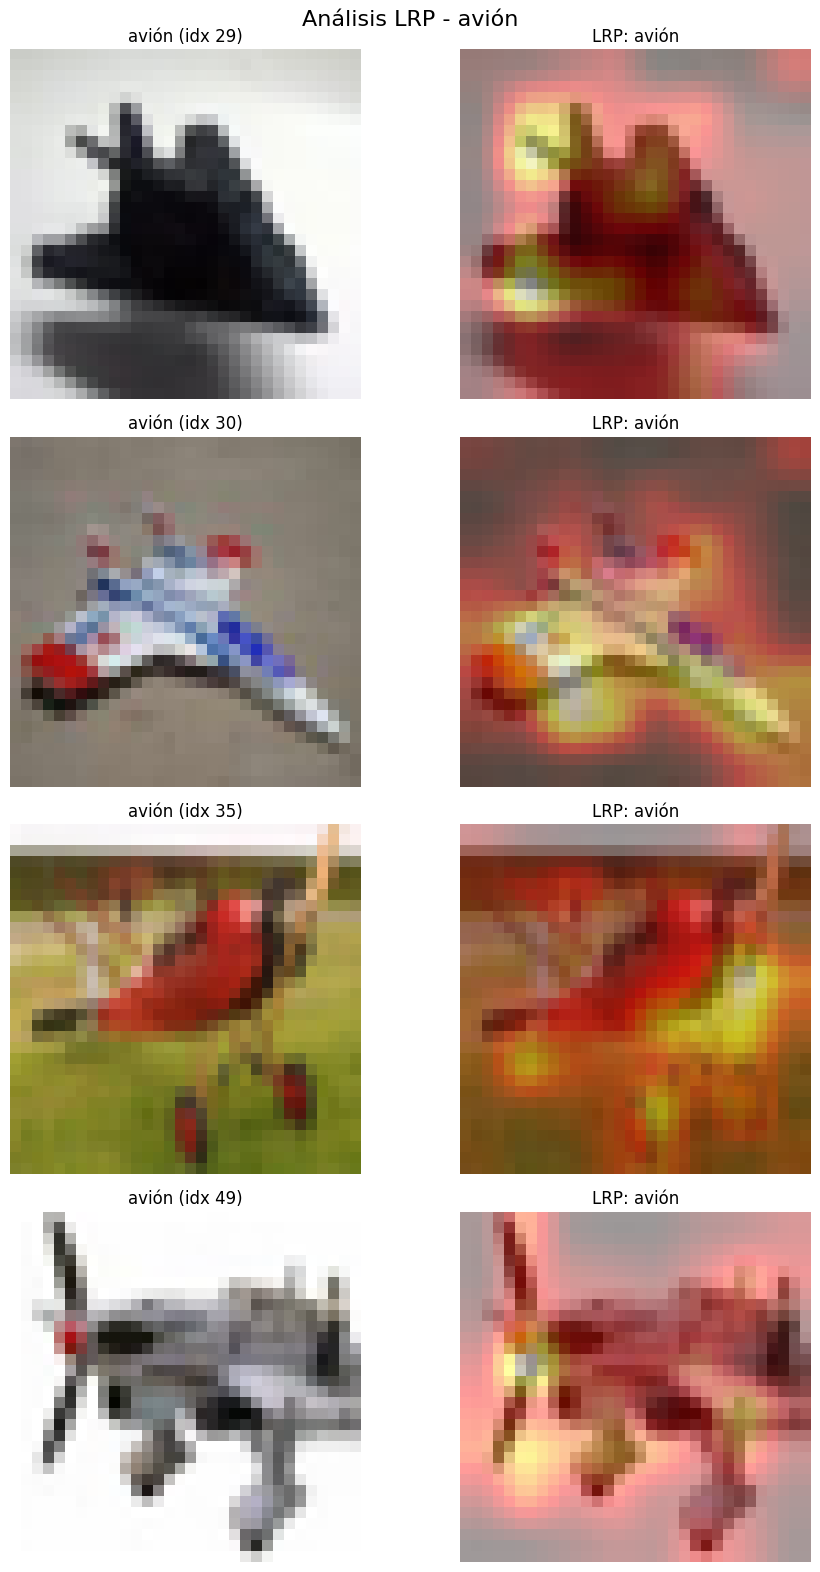

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


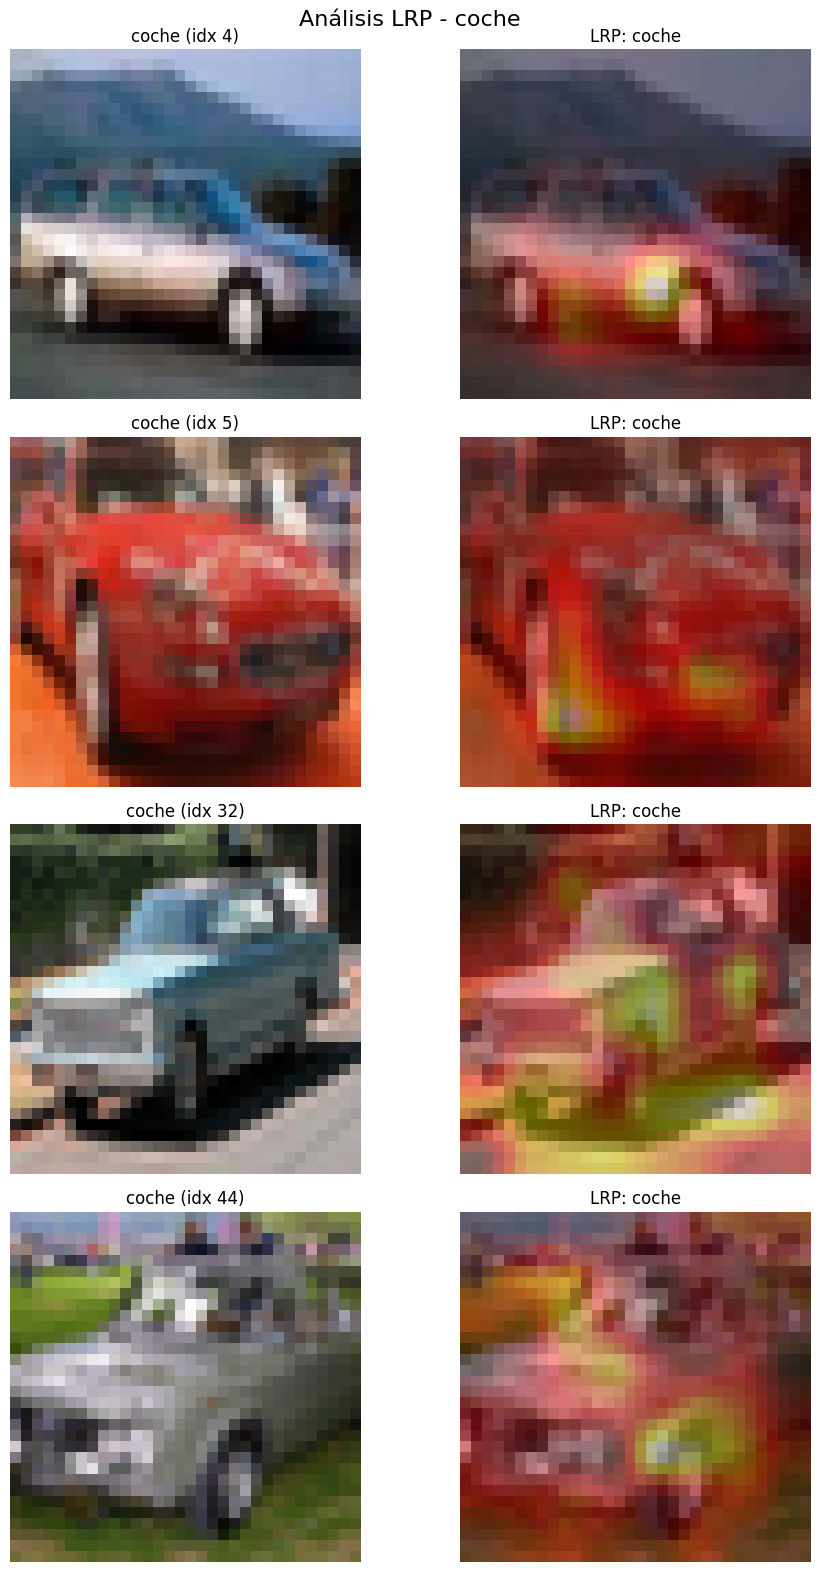

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


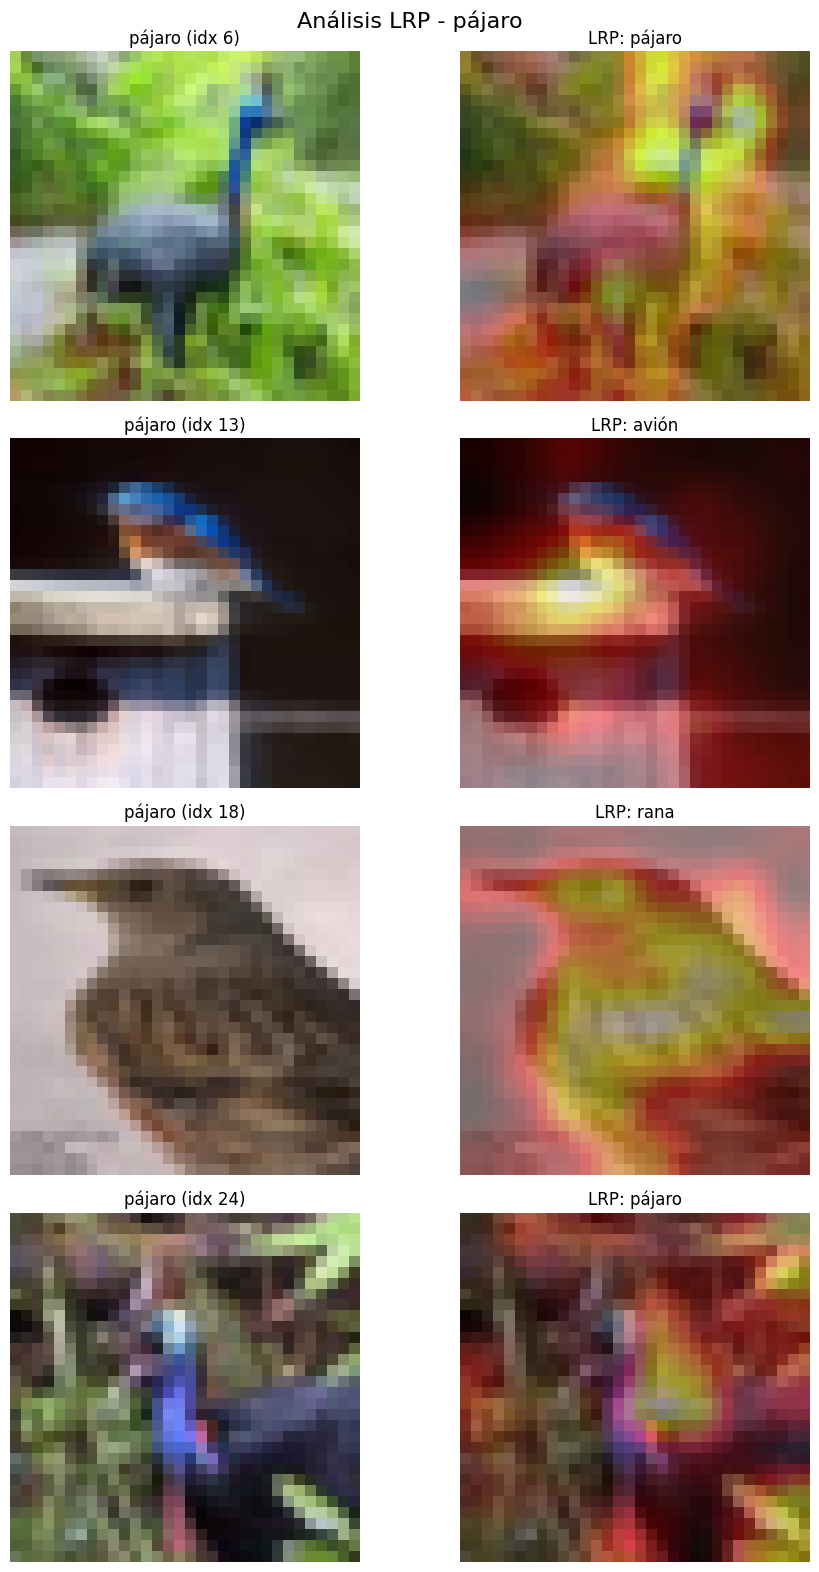

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


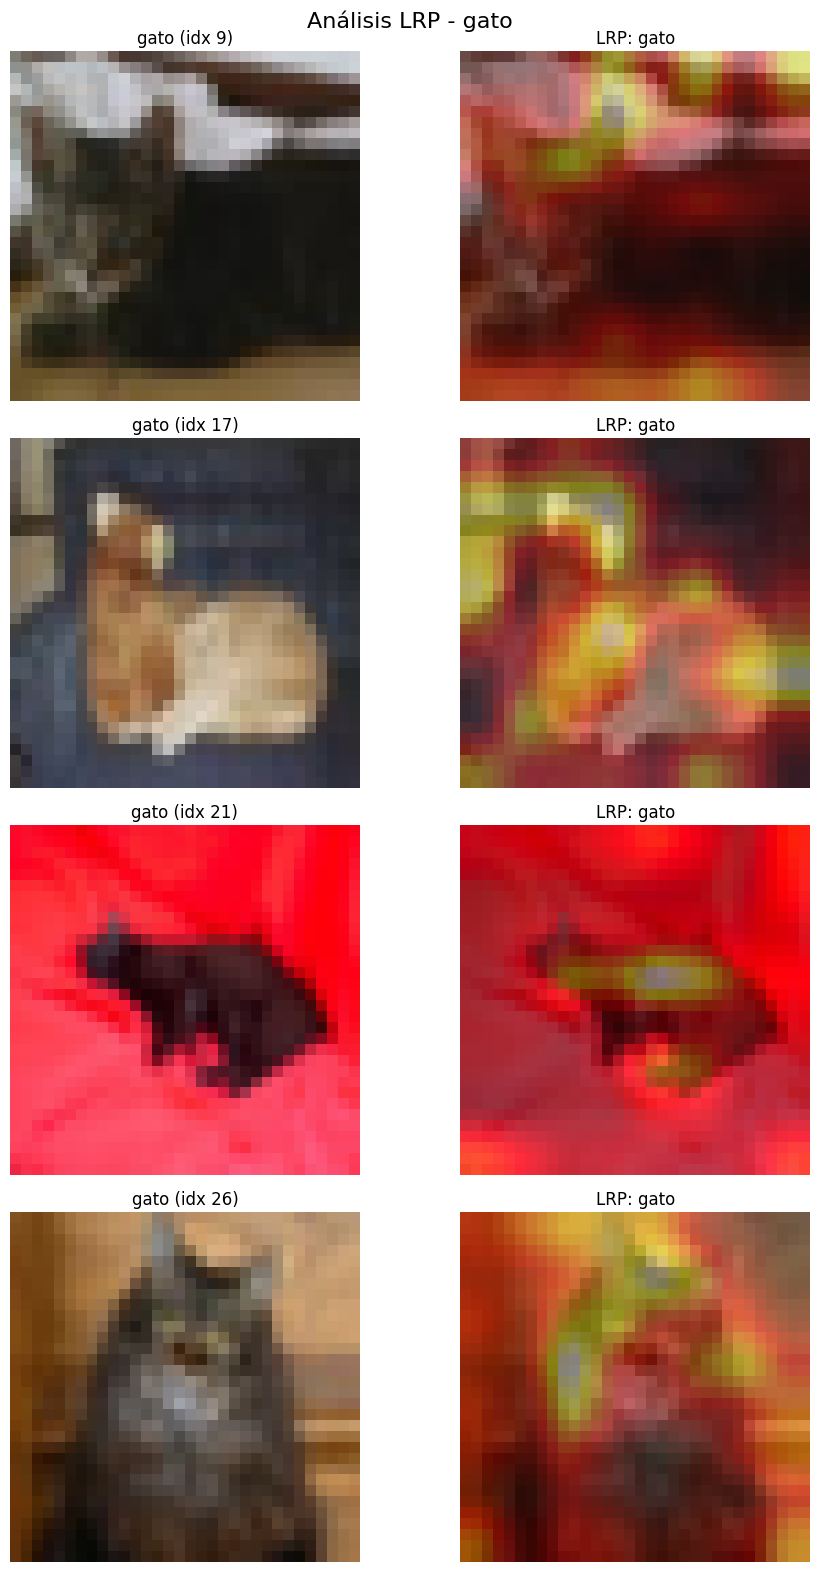

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


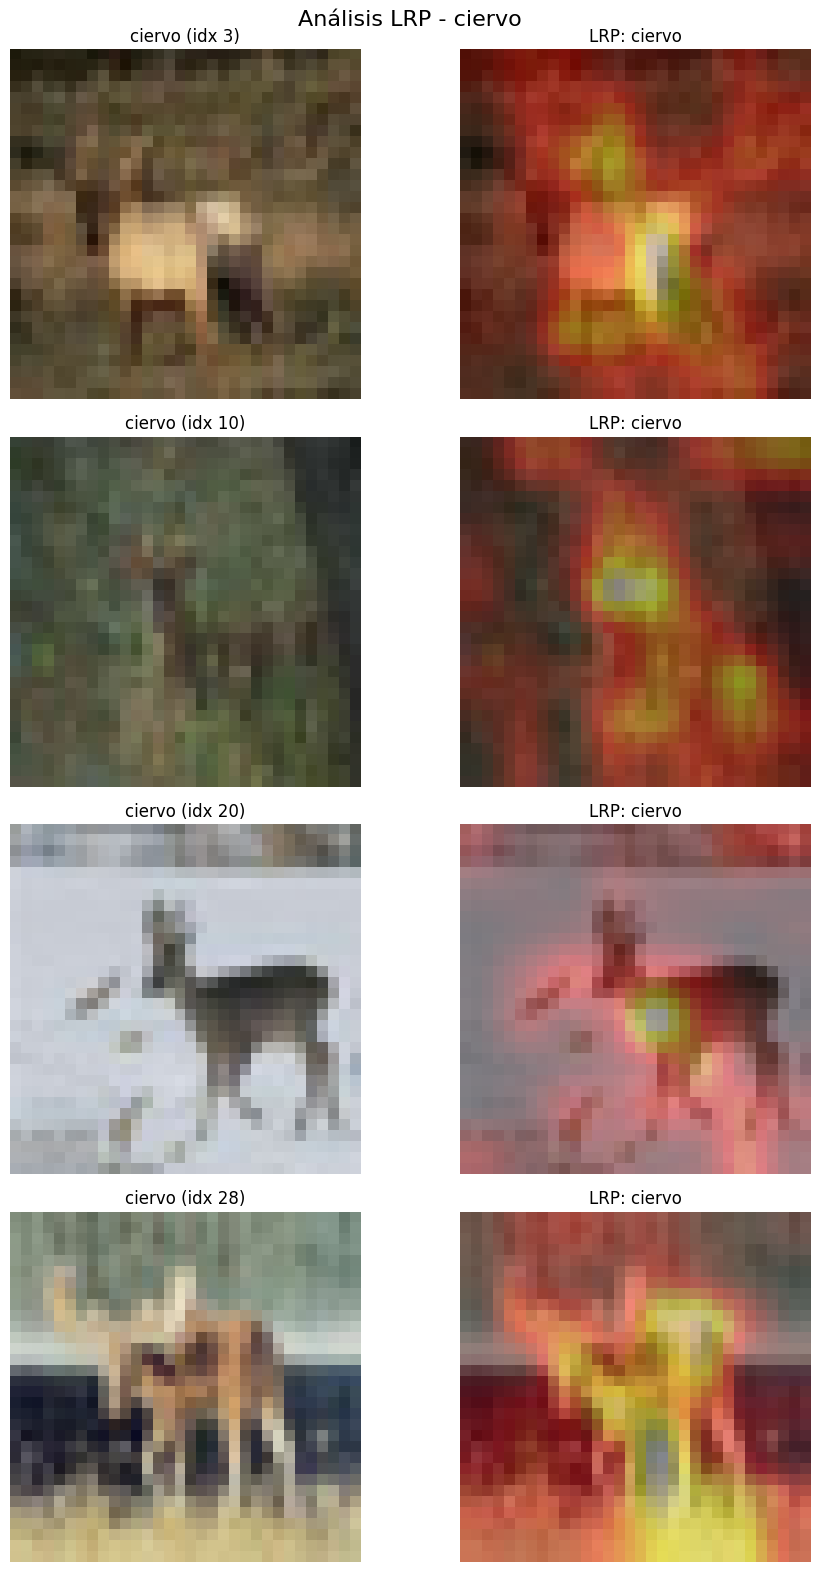

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


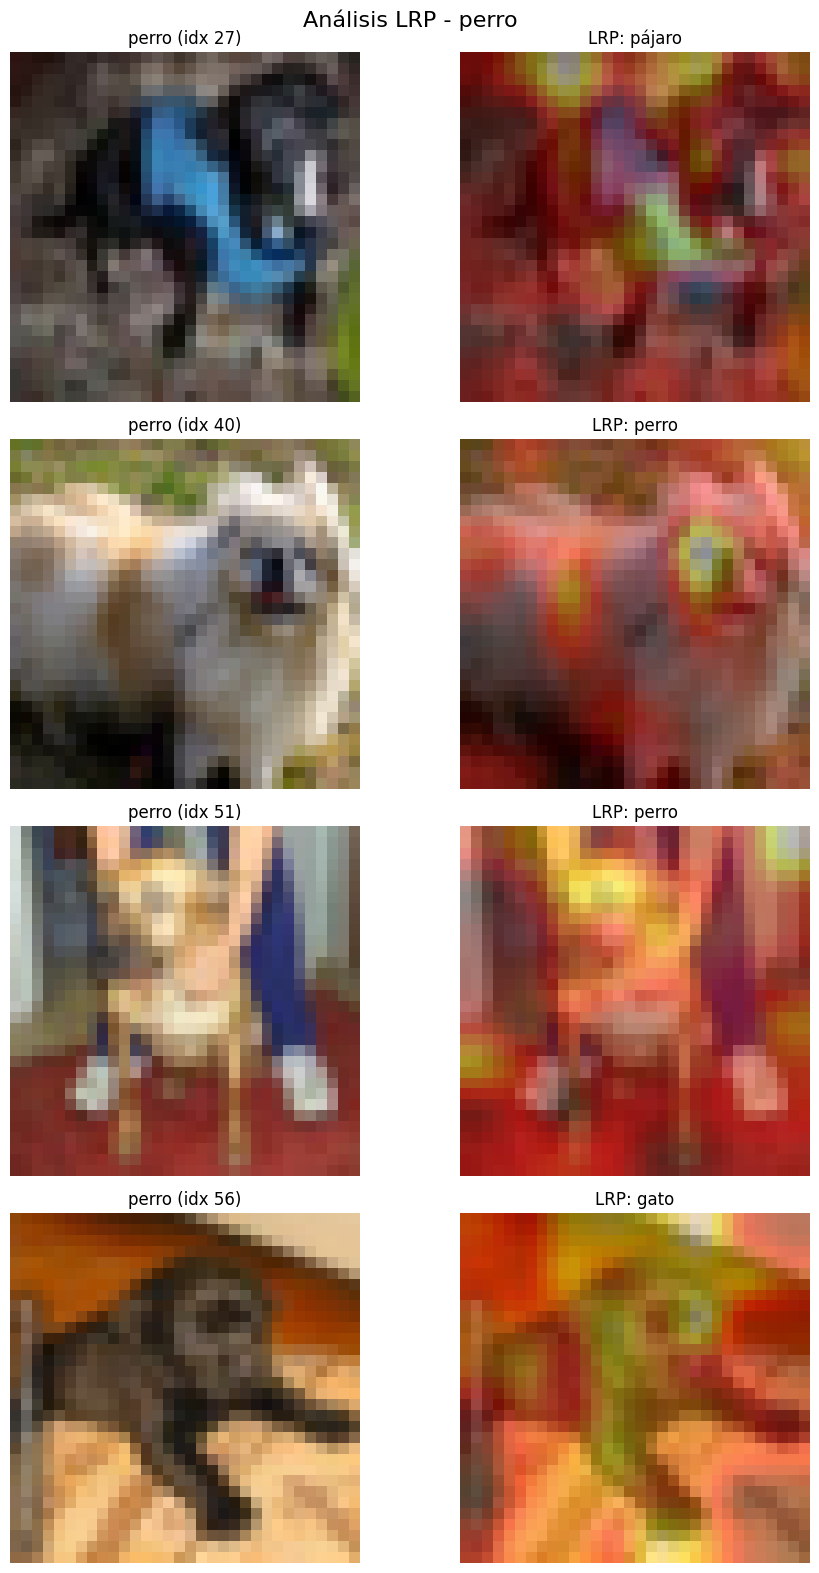

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


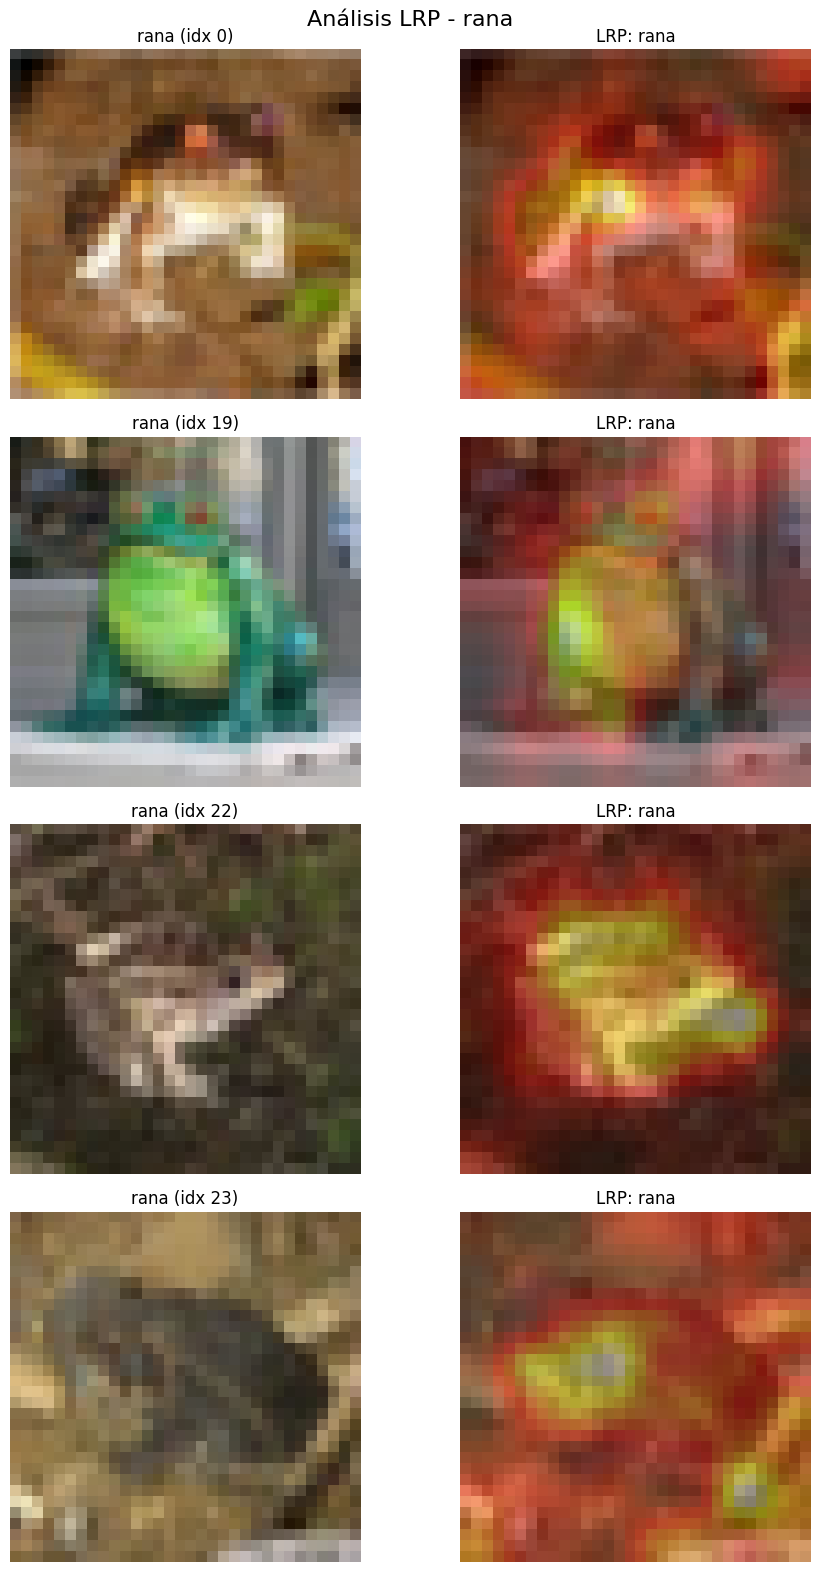

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


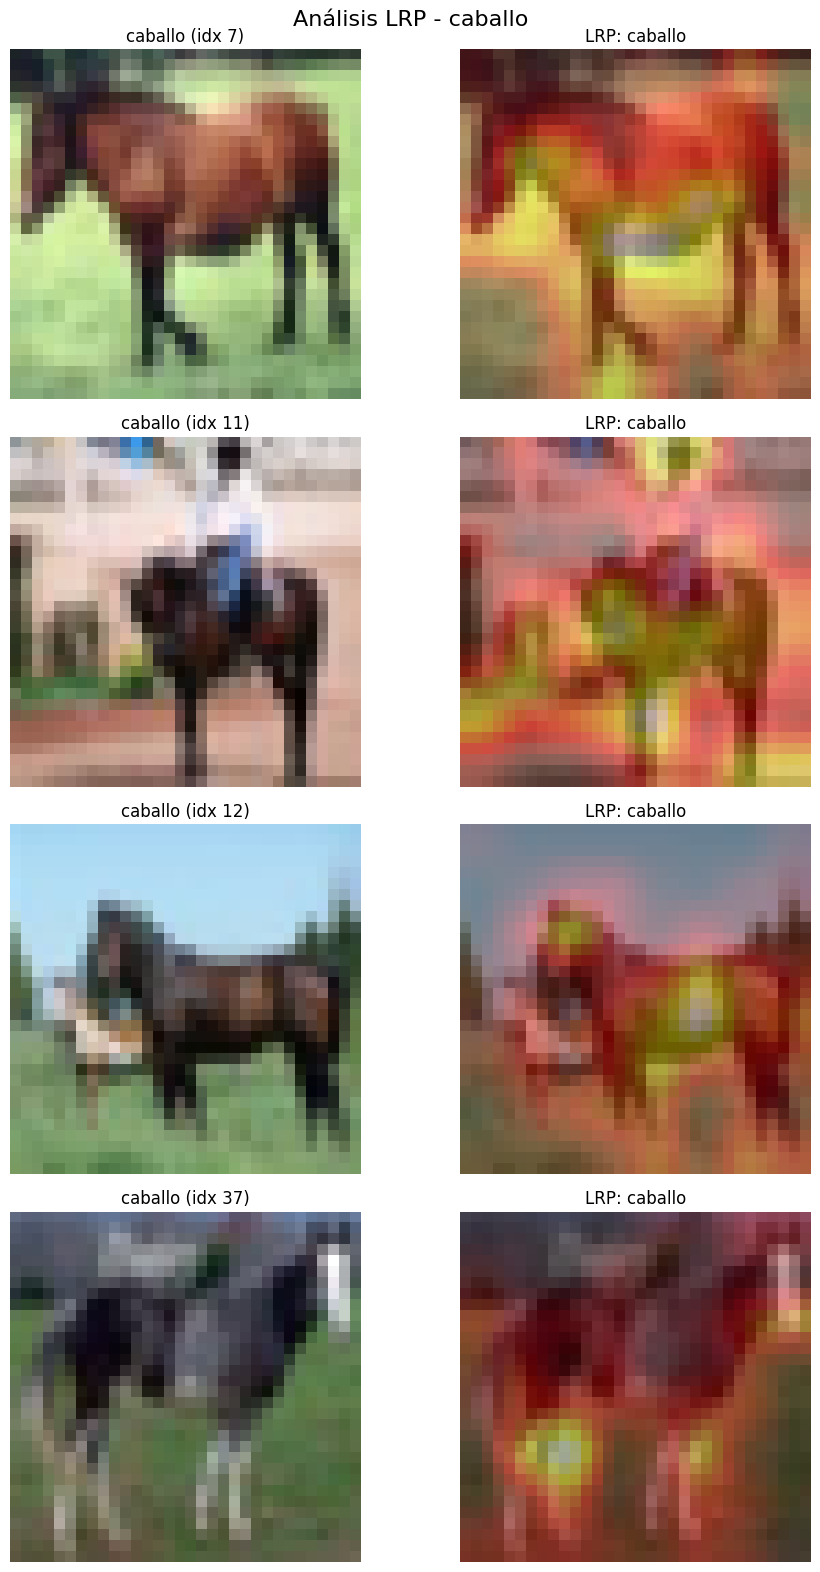

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


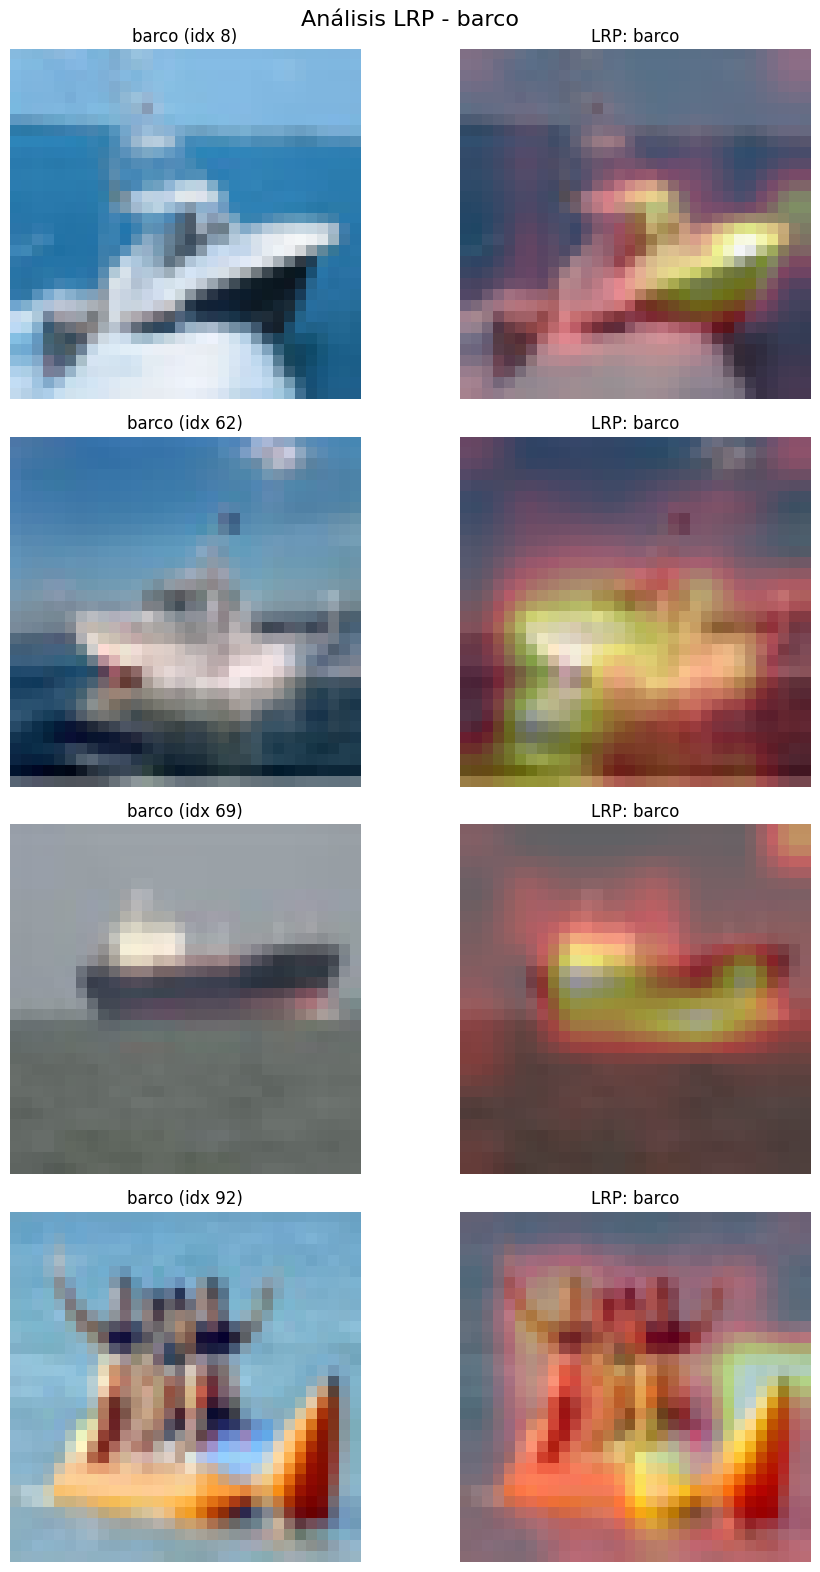

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


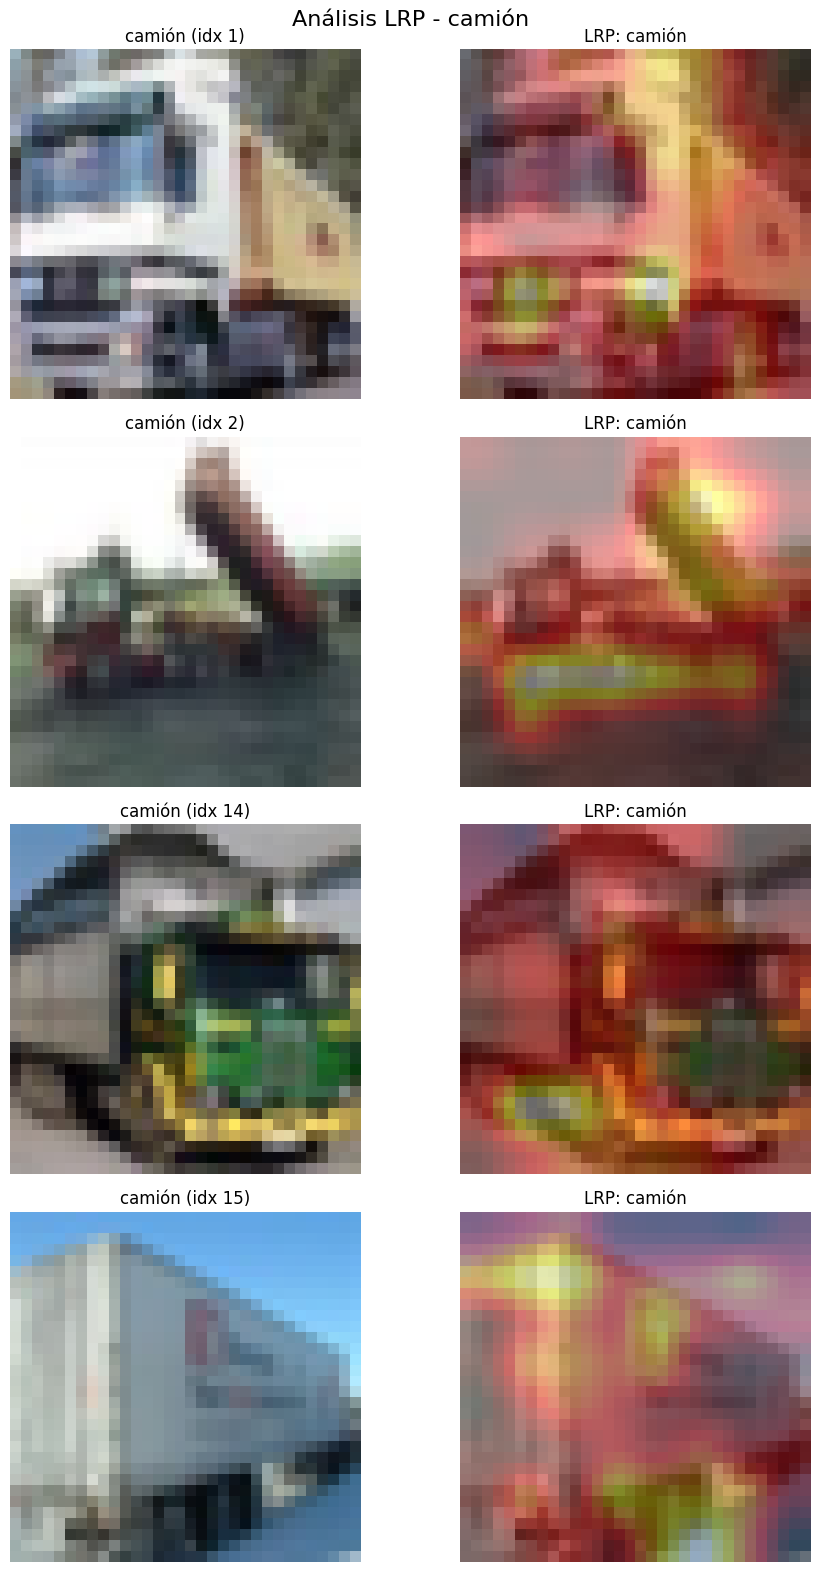

In [ ]:
for clase_idx in range(0,10):

    fig, axes = plt.subplots(4, 2, figsize=(10, 16))
    fig.suptitle(f"Análisis LRP - {clases[clase_idx]}", fontsize=16)

    axes = axes.flatten()

    indices = indices_por_clase(y_train, clase_idx)

    for i, idx_img in enumerate(indices[:4]):
        ax_img = axes[2*i]  # columna izquierda: imagen original
        ax_lrp = axes[2*i+1]  # columna derecha: LRP

        # Imagen original
        x_img = X_train[idx_img:idx_img+1]
        ax_img.imshow(x_img.reshape(32,32,3))
        ax_img.set_title(f"{clases[clase_idx]} (idx {idx_img})")
        ax_img.axis("off")

        # LRP
        # 1) Extraemos el mapa de features (H, W, C), p.ej. (1, 8, 8, C)
        x_feat = feature_model.predict(x_img)
        pred_proba = model.predict(x_img)
        prediccion = clases[np.argmax(pred_proba[0])]

        # 2) LRP solo en el clasificador
        R_feat = compute_lrp_classifier(classifier, x_feat)   # (1, H, W, C)

        # 3) Normalizar y reescalar a 32x32 para overlay
        R_map = R_feat[0]    # (H, W, C)
        R_map = np.mean(R_map, axis=-1)   # promedio sobre canales -> (H, W)

        R_norm = (R_map - R_map.min()) / (R_map.max() - R_map.min() + 1e-9)

        # Reescalar al tamaño original (32x32)
        R_resized = tf.image.resize(R_norm[..., np.newaxis], (32, 32)).numpy()[..., 0]

        ax_lrp.imshow(X_train[idx_img])
        ax_lrp.imshow(R_resized, cmap="hot", alpha=0.4)
        ax_lrp.set_title(f"LRP: {prediccion}")
        ax_lrp.axis("off")

    plt.tight_layout()
    plt.show()

Observamos que por lo general, se esta basando en los rasgos de cada categoría para predecir la clase. Por lo que esta aprendiendo de las imagenes sin hacer "trampas".

---